In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris  # Real data!

In [2]:
# Step 2.1: Load Iris dataset (your 1st ML data!)
iris=load_iris()
X=iris.data # 150 flowers × 4 features (sepal/petal)
print("Iris shape:", X.shape)
print("Features:", iris.feature_names) 

Iris shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [3]:
# Step 2.2: Covariance matrix (data "stretch map")
X_centered = X-X.mean(axis=0)
cov_matrix=np.cov(X_centered,rowvar=False)
print("\nCovariance:\n", cov_matrix.round(2))


Covariance:
 [[ 0.69 -0.04  1.27  0.52]
 [-0.04  0.19 -0.33 -0.12]
 [ 1.27 -0.33  3.12  1.3 ]
 [ 0.52 -0.12  1.3   0.58]]


In [5]:
# Step 2.3: EIGEN MAGIC! (numpy.linalg.eig)
eigenvalues,eigenvectors=np.linalg.eig(cov_matrix)
print("\nEigenvalues:", eigenvalues.round(3))  # Variance along each direction
print("Eigenvectors (directions):\n", eigenvectors.round(3))


Eigenvalues: [4.228 0.243 0.078 0.024]
Eigenvectors (directions):
 [[ 0.361 -0.657 -0.582  0.315]
 [-0.085 -0.73   0.598 -0.32 ]
 [ 0.857  0.173  0.076 -0.48 ]
 [ 0.358  0.075  0.546  0.754]]


In [7]:
# Sort by eigenvalue (biggest variance first)
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]
print("\nSorted Eigenvalues:", eigenvalues.round(3))
print("Top Eigenvector (PC1):\n", eigenvectors[:, 0].round(3))


Sorted Eigenvalues: [4.228 0.243 0.078 0.024]
Top Eigenvector (PC1):
 [ 0.361 -0.085  0.857  0.358]


In [8]:
# Step 2.4: PCA Project Data to 2D!
X_pca = X_centered @ eigenvectors[:, :2]  # Top 2 directions

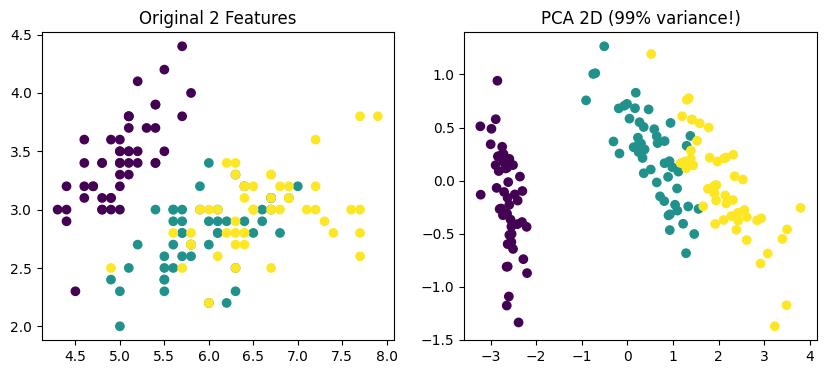

Variance explained by top 2: 97.8%


In [9]:
# Visualize
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.scatter(X[:,0], X[:,1], c=iris.target); plt.title('Original 2 Features')
plt.subplot(1,2,2); plt.scatter(X_pca[:,0], X_pca[:,1], c=iris.target); plt.title('PCA 2D (99% variance!)')
plt.show()
print(f"Variance explained by top 2: {eigenvalues[:2].sum() / eigenvalues.sum() * 100:.1f}%")